In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import random
import numpy as np

Matplotlib created a temporary config/cache directory at /tmp/matplotlib-bsfa3xkv because the default path (/tmp/cache/matplotlib) is not a writable directory; it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.
Matplotlib is building the font cache; this may take a moment.


## Stock investments

We will first import some data from stock market history prices over the last two years ("close" daily values). You will later learn how to use pandas, for now we will simplify the data, giving you with just the
numpy arrays needed to complete this question.

In [2]:
df_stocks = pd.read_csv('example_stock_close_prices.csv')

Consider the two time series of the Intel and Johnson & Johnson daily stock prices, given in the arrays (vectors) `p1` and `p2` respectively. The dates are given in the array `dates`.

In [3]:
p1 = df_stocks['Intel'].values
p2 = df_stocks['Johnson & Johnson'].values
dates = df_stocks['date'].values

In [4]:
T = len(dates)
print('Total number of days = ', T)

Total number of days =  507


This number makes sense! On average, a year will have about 252 trading days.

Note that for each time increment `t` where `t=0,...,T-1`, we can get the corresponding stock prices for the Intel and Johnson & Johnson stocks:

In [5]:
# for example, at t = 0
t = 0
p1[t]

60.55

In [6]:
# for example, at t = 20
t = 20
p2[t]

148.94

Recall that Python uses zero-indexing, so you will get an error if you try to evaluate the cell below:

In [7]:
dates[T]

IndexError: index 507 is out of bounds for axis 0 with size 507

Your data has stock prices in the following range:

In [ ]:
dates[0]

In [ ]:
dates[-1]

Take a look at the plot of the daily stock prices for these two companies:

Text(0.5, 1.0, 'Stock prices')

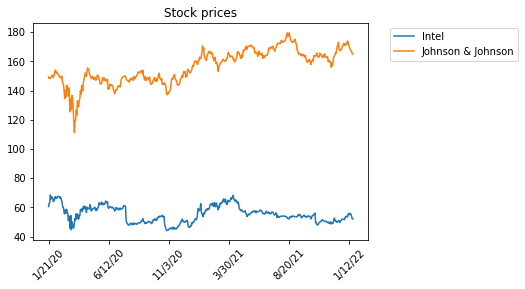

In [33]:
fig, ax = plt.subplots()
ax.plot(dates,p1,label='Intel')
ax.plot(dates,p2,label='Johnson & Johnson')
plt.legend(bbox_to_anchor=(1.05, 1))
ax.xaxis.set_major_locator(plt.MaxNLocator(6));
plt.xticks(rotation=45);
plt.title('Stock prices')

#### Question 1:

Suppose you could travel back in time to day zero `t = 0` and invest \$1000 in these two companies. 

Your stock portfolio can be defined as:

```
X1 p1[0] + X2 p2[0] = 1000
```

where `X1` and `X2` correspond to the number of shares of each company.

Find `X1` and `X2` such that the value of your investment at time `T-1` is $2000.

**Note:** `X1` and `X2` can be negative. Negative `X1` means you are shortselling the Intel stocks, and negative `X2` means you are shortstelling the Johnson & Johnson stocks.



In [35]:
#grade

# Perform some calculation here
first = np.array([p1[0], p2[0]])
end = np.array([p1[T-1], p2[T-1]])
val = np.array([first, end])
start = np.array([1000, 2000])

X1 = -60.35123452
X2 = 31.18019194

print(X1 * p1[T-1] + X2 * p2[T-1])
print(np.linalg.solve(val,start))

2000.0000007270005
[-60.35123452  31.18019194]


#### Question 2:

Plot the value of your investment over this time period, i.e. from `t = 0,1,...,T-1` (we are not grading this step).

Text(0.5, 1.0, 'Portfolio')

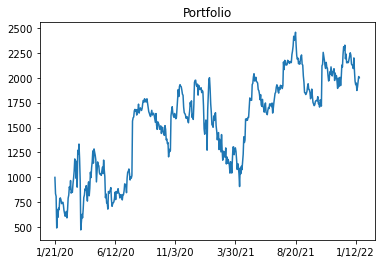

In [36]:
fig, ax = plt.subplots()
ax.plot(dates,X1 * p1 + X2 * p2,label='Money')
ax.xaxis.set_major_locator(plt.MaxNLocator(6));
plt.title('Portfolio')

#### Question 3:

What is the value of your investment at the end of the first quarter of year 1? Assume that that a trading year has 252 days, so the end of the first quarter will happen at `t = 62`. Assign your result to the variable `invt62`.

In [37]:
#grade
invt62 = X1 * p1[62] + X2 * p2[62]
invt62

1157.5136526461997

#### Question 4: 
    
Suppose you started your investment with 10 shares from both Intel and Johnson & Johnson (also from day `t = 0`).

- What is the value of your investment on day `t = 0`? Define the variable `invt0`.
- What is the value of your investment on day `t = T-1`? Define the variable `invtT`.


In [38]:
#grade
invt0 = 10 * (p1[0] + p2[0])
invtT = 10 * (p1[T-1] + p2[T-1])

Plot the value of your new investment over time.

Text(0.5, 1.0, 'Portfolio')

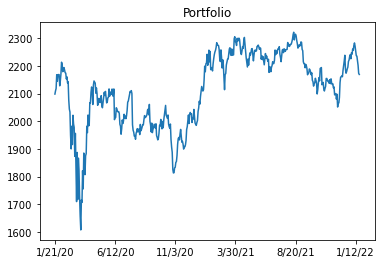

In [39]:
fig, ax = plt.subplots()
ax.plot(dates,10 * (p1 + p2) ,label='invt')

ax.xaxis.set_major_locator(plt.MaxNLocator(6));
plt.title('Portfolio')